In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load data đã xử lý
X = pd.read_csv("/app/data/processed/X_train_raw.csv")
y = pd.read_csv("/app/data/processed/y_train_raw.csv").squeeze()
# .squeeze() → chuyển DataFrame 1 cột thành Series

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: {y.min():.2f} → {y.max():.2f} (log scale)")
print(f"Tương đương: {np.expm1(y.min())/1e6:.1f}tr → {np.expm1(y.max())/1e6:.1f}tr VNĐ")

# Split 80% train / 20% test
# random_state=42 → kết quả tái lặp được mỗi lần chạy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} dòng")
print(f"Test : {X_test.shape[0]} dòng")

X shape: (892, 31)
y shape: (892,)
y range: 13.76 → 15.97 (log scale)
Tương đương: 1.0tr → 8.6tr VNĐ

Train: 713 dòng
Test : 179 dòng


In [2]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train model và đánh giá bằng nhiều metric.
    Tất cả metric được convert về VNĐ thật (expm1) để dễ hiểu.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Convert từ log scale về VNĐ thật
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred)

    # Các metric đánh giá
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    r2   = r2_score(y_test_real, y_pred_real)

    # Cross-validation 5-fold trên tập train
    kf     = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2  = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  R²        : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"  RMSE      : {rmse/1e6:.2f} triệu VNĐ")
    print(f"  MAE       : {mae/1e6:.2f} triệu VNĐ")
    print(f"  CV R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    return {
        "model":     model,
        "name":      model_name,
        "r2":        r2,
        "rmse":      rmse,
        "mae":       mae,
        "cv_r2":     cv_r2.mean(),
        "y_pred":    y_pred_real,
        "y_test":    y_test_real,
    }

In [3]:
results = {}

# ── Model 1: Linear Regression (baseline) ────────────────────
results["Linear"] = evaluate_model(
    LinearRegression(),
    X_train, X_test, y_train, y_test,
    "Linear Regression (baseline)"
)

# ── Model 2: Ridge Regression (Linear + regularization) ──────
# alpha=1.0 → mức regularization, giảm overfitting
results["Ridge"] = evaluate_model(
    Ridge(alpha=1.0),
    X_train, X_test, y_train, y_test,
    "Ridge Regression"
)

# ── Model 3: Random Forest ────────────────────────────────────
# n_estimators=100 → 100 cây quyết định
# max_depth=10     → giới hạn độ sâu mỗi cây, tránh overfit
results["RF"] = evaluate_model(
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Random Forest"
)

# ── Model 4: Gradient Boosting ────────────────────────────────
# Thường cho kết quả tốt nhất với tabular data
results["GB"] = evaluate_model(
    GradientBoostingRegressor(n_estimators=200, max_depth=4,
                               learning_rate=0.05, random_state=42),
    X_train, X_test, y_train, y_test,
    "Gradient Boosting"
)


  Linear Regression (baseline)
  R²        : 0.4147  (41.5% variance explained)
  RMSE      : 0.98 triệu VNĐ
  MAE       : 0.77 triệu VNĐ
  CV R² (5-fold): 0.4201 ± 0.0538

  Ridge Regression
  R²        : 0.4303  (43.0% variance explained)
  RMSE      : 0.96 triệu VNĐ
  MAE       : 0.77 triệu VNĐ
  CV R² (5-fold): 0.4236 ± 0.0598

  Random Forest
  R²        : 0.4055  (40.5% variance explained)
  RMSE      : 0.99 triệu VNĐ
  MAE       : 0.74 triệu VNĐ
  CV R² (5-fold): 0.3524 ± 0.0712

  Gradient Boosting
  R²        : 0.4477  (44.8% variance explained)
  RMSE      : 0.95 triệu VNĐ
  MAE       : 0.72 triệu VNĐ
  CV R² (5-fold): 0.3804 ± 0.0452


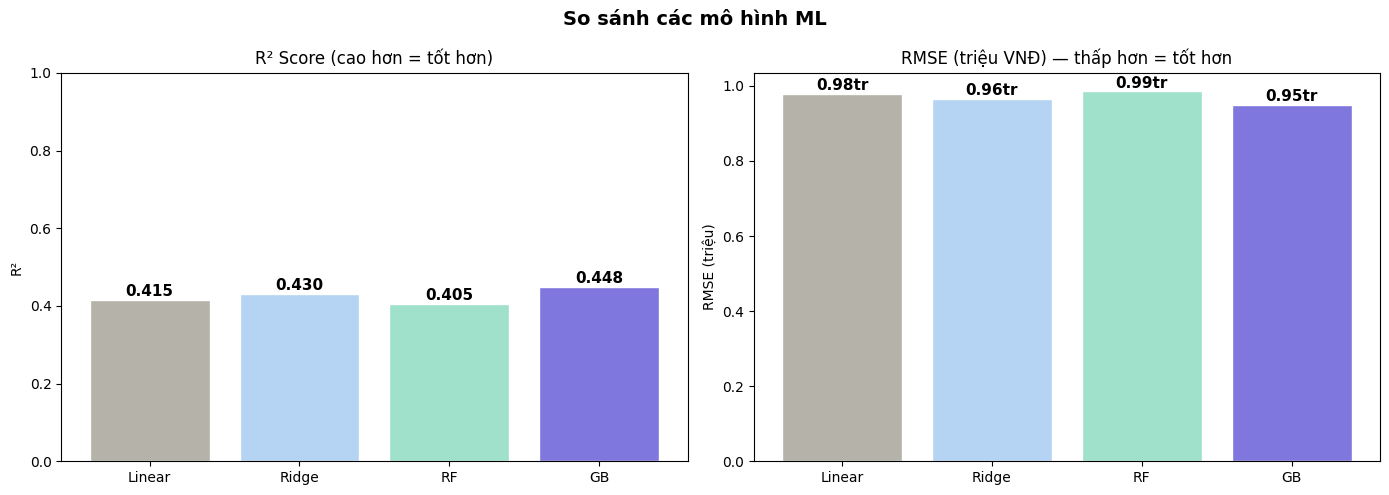


=== BẢNG SO SÁNH ===
            R² RMSE(tr) MAE(tr)   CV R²
Model                                  
Linear  0.4147     0.98    0.77  0.4201
Ridge   0.4303     0.96    0.77  0.4236
RF      0.4055     0.99    0.74  0.3524
GB      0.4477     0.95    0.72  0.3804

Model tốt nhất: GB — R²=0.4477, RMSE=0.95tr


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: So sánh R² và RMSE ──────────────────────────────
model_names = list(results.keys())
r2_scores   = [results[m]["r2"]      for m in model_names]
rmse_scores = [results[m]["rmse"]/1e6 for m in model_names]

colors = ["#B4B2A9", "#B5D4F4", "#9FE1CB", "#7F77DD"]

axes[0].bar(model_names, r2_scores, color=colors, edgecolor="white")
axes[0].set_title("R² Score (cao hơn = tốt hơn)")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

axes[1].bar(model_names, rmse_scores, color=colors, edgecolor="white")
axes[1].set_title("RMSE (triệu VNĐ) — thấp hơn = tốt hơn")
axes[1].set_ylabel("RMSE (triệu)")
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.01, f"{v:.2f}tr", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("So sánh các mô hình ML", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/app/data/model_comparison.png", dpi=150)
plt.show()

# ── In bảng tóm tắt ──────────────────────────────────────────
print("\n=== BẢNG SO SÁNH ===")
summary = pd.DataFrame({
    "Model":    model_names,
    "R²":       [f"{results[m]['r2']:.4f}"       for m in model_names],
    "RMSE(tr)": [f"{results[m]['rmse']/1e6:.2f}" for m in model_names],
    "MAE(tr)":  [f"{results[m]['mae']/1e6:.2f}"  for m in model_names],
    "CV R²":    [f"{results[m]['cv_r2']:.4f}"    for m in model_names],
}).set_index("Model")
print(summary)

# Tìm model tốt nhất theo R²
best_name = max(results, key=lambda m: results[m]["r2"])
best      = results[best_name]
print(f"\nModel tốt nhất: {best_name} — R²={best['r2']:.4f}, RMSE={best['rmse']/1e6:.2f}tr")

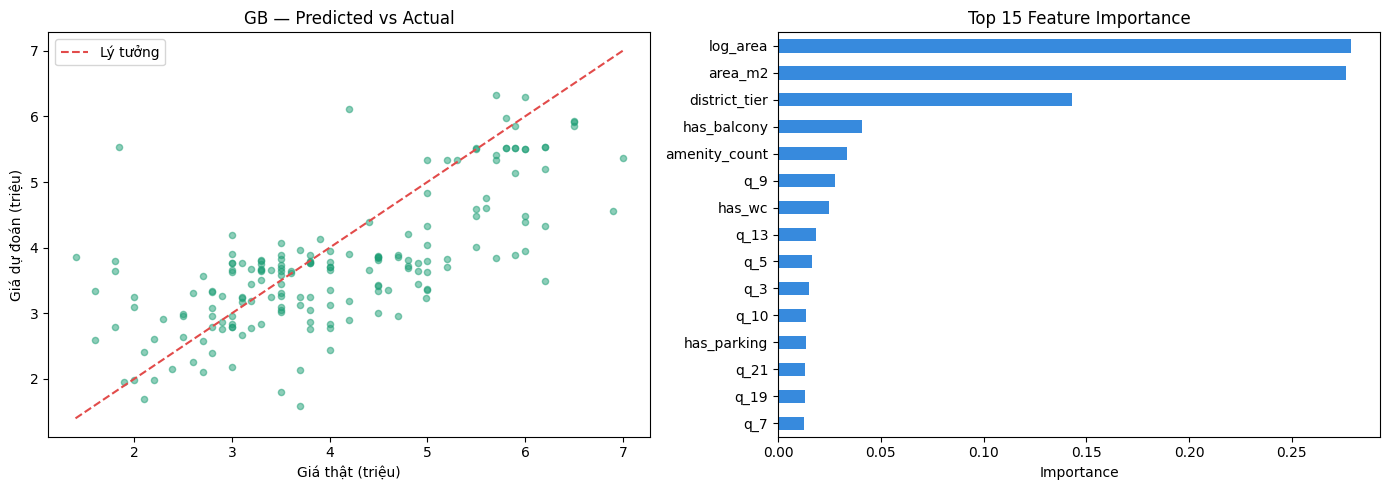

In [5]:
best_result = results[best_name]
best_model  = best_result["model"]

# ── Chart: Predicted vs Actual ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_test_real = best_result["y_test"]
y_pred_real = best_result["y_pred"]

axes[0].scatter(y_test_real/1e6, y_pred_real/1e6,
                alpha=0.5, color="#1D9E75", s=20)
# Đường lý tưởng: predicted = actual
min_val = min(y_test_real.min(), y_pred_real.min()) / 1e6
max_val = max(y_test_real.max(), y_pred_real.max()) / 1e6
axes[0].plot([min_val, max_val], [min_val, max_val],
             color="#E24B4A", linewidth=1.5, linestyle="--", label="Lý tưởng")
axes[0].set_xlabel("Giá thật (triệu)")
axes[0].set_ylabel("Giá dự đoán (triệu)")
axes[0].set_title(f"{best_name} — Predicted vs Actual")
axes[0].legend()

# ── Chart: Feature Importance (nếu là tree-based model) ──────
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    top15 = importance.nlargest(15).sort_values()

    top15.plot(kind="barh", ax=axes[1], color="#378ADD")
    axes[1].set_title("Top 15 Feature Importance")
    axes[1].set_xlabel("Importance")
else:
    # Linear model: dùng coefficients
    coef = pd.Series(best_model.coef_, index=X.columns)
    top15 = coef.abs().nlargest(15).sort_values()
    top15.plot(kind="barh", ax=axes[1], color="#378ADD")
    axes[1].set_title("Top 15 Feature Coefficients (abs)")

plt.tight_layout()
plt.savefig("/app/data/best_model_analysis.png", dpi=150)
plt.show()

In [8]:
import joblib
import os

os.makedirs("/app/models", exist_ok=True)

# Lưu model tốt nhất
joblib.dump(best_model, f"/app/models/best_model.pkl")
joblib.dump(X.columns.tolist(), "/app/models/feature_cols.pkl")
print(f"Đã lưu model: /app/models/best_model.pkl")

# ── Demo dự đoán thử ─────────────────────────────────────────
def predict_price(area_m2, district_id, has_ac=0, has_wc=0,
                  has_kitchen=0, has_parking=0, has_balcony=0, has_security=0):
    """Dự đoán giá thuê dựa trên thông tin phòng."""

    feature_cols = joblib.load("/app/models/feature_cols.pkl")

    # Tạo vector feature toàn 0
    input_data = pd.DataFrame([{col: 0 for col in feature_cols}])

    # Điền thông tin thật
    district_tier_map = {
        **{i: 2 for i in [1, 2, 3, 4, 7]},       # cao cấp
        **{i: 1 for i in [5, 6, 8, 10, 13, 17]},  # trung bình
        **{i: 0 for i in [20, 21, 22, 23, 24]},   # bình dân
    }

    input_data["area_m2"]        = area_m2
    input_data["log_area"]       = np.log1p(area_m2)
    input_data["district_tier"]  = district_tier_map.get(district_id, 1)
    input_data["has_ac"]         = has_ac
    input_data["has_wc"]         = has_wc
    input_data["has_kitchen"]    = has_kitchen
    input_data["has_parking"]    = has_parking
    input_data["has_balcony"]    = has_balcony
    input_data["has_security"]   = has_security
    input_data["amenity_count"]  = has_ac + has_wc + has_kitchen + has_parking + has_balcony + has_security

    # One-hot quận
    col_name = f"q_{district_id}"
    if col_name in input_data.columns:
        input_data[col_name] = 1

    log_pred = best_model.predict(input_data)[0]
    price    = np.expm1(log_pred)
    return price

# Test thử
test_cases = [
    {"area_m2": 20, "district_id": 1,  "has_ac": 1, "has_wc": 1},
    {"area_m2": 25, "district_id": 13, "has_ac": 0, "has_wc": 1},
    {"area_m2": 30, "district_id": 7,  "has_ac": 1, "has_wc": 1, "has_kitchen": 1},
    {"area_m2": 15, "district_id": 20, "has_wc": 1},
]
DISTRICT_MAP = {
    1: 'Quận 1', 2: 'Quận 2', 3: 'Quận 3', 4: 'Quận 4', 5: 'Quận 5',
    6: 'Quận 6', 7: 'Quận 7', 8: 'Quận 8', 9: 'Quận 9', 10: 'Quận 10',
    11: 'Quận 11', 12: 'Quận 12', 13: 'Bình Thạnh', 14: 'Bình Tân',
    15: 'Gò Vấp', 16: 'Phú Nhuận', 17: 'Tân Bình', 18: 'Tân Phú',
    19: 'Thủ Đức', 20: 'Bình Chánh', 21: 'Hóc Môn', 22: 'Nhà Bè',
    23: 'Cần Giờ', 24: 'Củ Chi'
}

print("=== DỰ ĐOÁN THỬ ===")
for case in test_cases:
    price = predict_price(**case)
    district_name = DISTRICT_MAP.get(case["district_id"], "?")
    print(f"  {case['area_m2']}m² | {district_name:12} | "
          f"AC={case.get('has_ac',0)} WC={case.get('has_wc',0)} "
          f"→ {price/1e6:.2f} triệu/tháng")

Đã lưu model: /app/models/best_model.pkl
=== DỰ ĐOÁN THỬ ===
  20m² | Quận 1       | AC=1 WC=1 → 3.10 triệu/tháng
  25m² | Bình Thạnh   | AC=0 WC=1 → 2.83 triệu/tháng
  30m² | Quận 7       | AC=1 WC=1 → 2.99 triệu/tháng
  15m² | Bình Chánh   | AC=0 WC=1 → 1.39 triệu/tháng
